# BESS-JPL Sensitivity Analysis with ECOv002 Cal-Val

This notebook performs a sensitivity analysis of the BESS-JPL model using ECOSTRESS Collection 2 Cal-Val data. It loads input data, processes it through the BESS-JPL model, and visualizes the impact of input perturbations on latent heat flux. The notebook also generates figures for publication and explores the relationship between surface temperature and latent heat flux.

## Import Required Libraries and Functions

This cell imports all necessary libraries and functions for data processing, model execution, statistical analysis, and plotting. It includes custom modules for the BESS-JPL model, sensitivity analysis, and net radiation calculations, as well as standard scientific Python libraries.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.path.dirname("__file__"), '..')))

In [2]:
from typing import Callable
from os import makedirs
from os.path import join
import numpy as np
import pandas as pd
from BESS_JPL import process_BESS_table, load_ECOv002_calval_BESS_inputs
from monte_carlo_sensitivity import perturbed_run, sensitivity_analysis, divide_absolute_by_unperturbed
import matplotlib.pyplot as plt
from scipy.stats import mstats
import seaborn as sns
from matplotlib.ticker import FuncFormatter

## Set Normalization Function

This cell assigns the normalization function used to compare perturbed model outputs to the unperturbed baseline. The function `divide_absolute_by_unperturbed` is used for normalization in the sensitivity analysis.

In [3]:
normalization_function = divide_absolute_by_unperturbed

## Load and Filter Input Data

This cell loads the ECOSTRESS Cal-Val input data using a custom loader function. The resulting DataFrame is displayed for inspection.

In [4]:
input_df = load_ECOv002_calval_BESS_inputs()
input_df

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,kn,peakVCmax_C3,peakVCmax_C4,ball_berry_slope_C3,ball_berry_slope_C4,ball_berry_intercept_C3,CI,canopy_height_meters,Ca,wind_speed_mps
0,0,US-NC3,ENF,Cfa,270.345200,78.53355,392.851840,307.021970,487.383423,118.916280,...,0.41,87.345433,51.040624,9.5,4.951963,0.005267,0.282353,20.642902,400,0
1,1,US-Mi3,CVM,Dfb,232.141600,229.20093,640.118470,375.089300,106.825577,167.919460,...,0.41,119.435443,119.435443,7.5,4.121171,0.009882,0.286275,0.000000,400,0
2,2,US-Mi3,CVM,Dfb,356.355740,335.23154,625.661700,284.686250,NaN,132.936340,...,0.41,119.435443,119.435443,7.5,4.121171,0.009882,0.286275,0.000000,400,0
3,3,US-Mi3,CVM,Dfb,332.938400,326.68680,624.254330,251.414490,178.827545,141.132420,...,0.41,119.435443,119.435443,7.5,4.121171,0.009882,0.286275,0.000000,400,0
4,4,US-Mi3,CVM,Dfb,286.854030,237.21654,511.082180,228.520170,154.791626,114.809410,...,0.41,119.435443,119.435443,7.5,4.121171,0.009882,0.286275,0.000000,400,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060,1060,US-xAE,GRA,Cfa,70.923310,172.37459,81.645230,15.282976,NaN,56.385185,...,0.71,78.000000,40.000000,9.5,5.800000,0.015000,0.301961,0.000000,400,0
1061,1061,US-xAE,GRA,Cfa,116.543190,121.81641,65.469320,22.186659,NaN,40.509410,...,0.71,78.000000,40.000000,9.5,5.800000,0.015000,0.301961,0.000000,400,0
1062,1062,US-xAE,GRA,Cfa,129.880100,0.00000,118.777240,55.343586,NaN,52.403820,...,0.71,78.000000,40.000000,9.5,5.800000,0.015000,0.301961,0.000000,400,0
1063,1063,US-xAE,GRA,Cfa,2.707851,140.38632,126.490524,40.434025,NaN,57.769722,...,0.71,78.000000,40.000000,9.5,5.800000,0.015000,0.301961,0.000000,400,0


## Process Input Data Through Model

This cell applies the processing function to the filtered input data, running it through the Verma net radiation and PT-JPL-SM model, and displays the resulting DataFrame.

In [5]:
processed = process_BESS_table(input_df)
processed

[2025-12-22 14:53:42 INFO] started extracting geometry from BESS input table
[2025-12-22 14:53:42 INFO] completed extracting geometry from PT-JPL-SM input table
[2025-12-22 14:53:42 INFO] started extracting time from BESS input table
[2025-12-22 14:53:42 INFO] All GEOS-5 FP inputs provided, no retrieval needed.
[2025-12-22 14:53:42 INFO] completed extracting time from PT-JPL-SM input table
[2025-12-22 14:53:42 INFO] variable elevation_m min: 1.000 mean: 992.883 max: 3504.000 nan: 0.00% (nan)
[2025-12-22 14:53:42 INFO] All GEOS-5 FP inputs provided, no retrieval needed.
[2025-12-22 14:53:42 INFO] variable Ta_C min: -14.605 mean: 22.322 max: 39.710 nan: 0.00% (nan)
[2025-12-22 14:53:42 INFO] variable RH min: 0.273 mean: 0.427 max: 0.984 nan: 0.00% (nan)
[2025-12-22 14:53:42 INFO] variable NDVI_minimum min: -0.033 mean: 0.174 max: 0.591 nan: 0.00% (nan)
[2025-12-22 14:53:42 INFO] variable NDVI_maximum min: 0.314 mean: 0.628 max: 0.918 nan: 0.00% (nan)
[2025-12-22 14:53:42 INFO] variable C

,Unnamed: 0,ID,vegetation,climate,STICinst,BESSinst,MOD16inst,PTJPLSMinst,ETinst,ETinstUncertainty,...,wind_speed_mps,GPP,GPP_daily,Rn_Wm2,Rn_soil_Wm2,Rn_canopy_Wm2,LE_Wm2,LE_soil_Wm2,LE_canopy_Wm2,G_Wm2
0,0,US-NC3,ENF,Cfa,270.345200,78.53355,392.851840,307.021970,487.383423,118.916280,...,0,15.616766,5.711566,466.357577,297.381272,168.976305,203.719064,59.270467,144.448597,35.791947
1,1,US-Mi3,CVM,Dfb,232.141600,229.20093,640.118470,375.089300,106.825577,167.919460,...,0,21.021739,8.598512,709.085679,543.104519,165.981159,231.554366,95.668201,135.886166,74.268917
2,2,US-Mi3,CVM,Dfb,356.355740,335.23154,625.661700,284.686250,NaN,132.936340,...,0,19.975842,8.116796,725.946606,543.887475,182.059132,342.611996,191.189198,151.422799,74.709546
3,3,US-Mi3,CVM,Dfb,332.938400,326.68680,624.254330,251.414490,178.827545,141.132420,...,0,24.097524,10.306391,694.866890,512.976422,181.890468,343.846632,195.970016,147.876616,68.422568
4,4,US-Mi3,CVM,Dfb,286.854030,237.21654,511.082180,228.520170,154.791626,114.809410,...,0,21.499935,10.067692,547.270243,407.281997,139.988246,241.447121,128.088996,113.358125,55.898896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1060,1060,US-xAE,GRA,Cfa,70.923310,172.37459,81.645230,15.282976,NaN,56.385185,...,0,0.492825,0.193133,231.107920,163.076093,68.031827,67.543019,40.764830,26.778189,29.014390
1061,1061,US-xAE,GRA,Cfa,116.543190,121.81641,65.469320,22.186659,NaN,40.509410,...,0,1.258465,0.881543,247.155614,177.971270,69.184344,68.284042,28.962675,39.321368,31.763235
1062,1062,US-xAE,GRA,Cfa,129.880100,0.00000,118.777240,55.343586,NaN,52.403820,...,0,3.354856,2.400564,386.798873,254.162932,132.635940,101.355173,5.927288,95.427886,34.809273
1063,1063,US-xAE,GRA,Cfa,2.707851,140.38632,126.490524,40.434025,NaN,57.769722,...,0,1.985566,1.197199,295.591819,234.818866,60.772954,77.026117,46.078914,30.947204,43.789133


## Accuracy Comparison of In-Situ Net Radiation to BESS-JPL Net Radiation

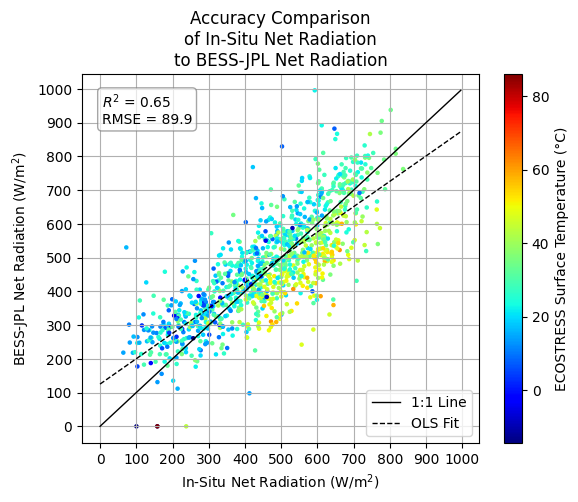

In [6]:
sc = plt.scatter(
    x=processed.NETRAD_filt,
    y=processed.Rn_Wm2,
    c=processed.ST_C,
    cmap="jet",
    color=None,
    s=5
)

# Add 1-to-1 line
min_val = min(processed.NETRAD_filt.min(), processed.Rn_Wm2.min())
max_val = max(processed.NETRAD_filt.max(), processed.Rn_Wm2.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='-', linewidth=1, label='1:1 Line')

# Add OLS regression line
coefs = np.polyfit(processed.NETRAD_filt, processed.Rn_Wm2, 1)
ols_x = np.array([min_val, max_val])
ols_y = coefs[0] * ols_x + coefs[1]
plt.plot(ols_x, ols_y, color='black', linestyle='--', linewidth=1, label='OLS Fit')

# Calculate R-squared and RMSE
from sklearn.metrics import r2_score, mean_squared_error
y_true = processed.Rn_Wm2
y_pred = coefs[0] * processed.NETRAD_filt + coefs[1]
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# Annotate R-squared and RMSE on plot
plt.annotate(f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.1f}",
             xy=(0.05, 0.95), xycoords='axes fraction',
             ha='left', va='top',
             fontsize=10,
             bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.7))

# Set ticks every 100 for both axes
xticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
yticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
plt.xticks(xticks)
plt.yticks(yticks)

plt.grid(True, zorder=0) 
plt.xlabel("In-Situ Net Radiation (W/m$^2$)")
plt.ylabel("BESS-JPL Net Radiation (W/m$^2$)")
plt.title("Accuracy Comparison\nof In-Situ Net Radiation\nto BESS-JPL Net Radiation")
plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")
plt.legend()
plt.savefig("Unperturbed Comparison of In-Situ Net Radiation to BESS-JPL Net Radiation.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Unperturbed Comparison of In-Situ Net Radiation to BESS-JPL Net Radiation.svg", format='svg', bbox_inches='tight')
plt.show()

## Accuracy Comparison of In-Situ Net Radiation to BESS-JPL Latent Heat Flux

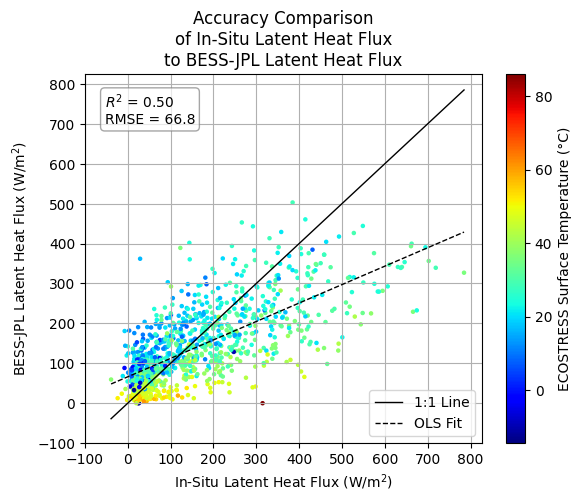

In [7]:
sc = plt.scatter(
    x=processed.LEcorr50,
    y=processed.LE_Wm2,
    c=processed.ST_C,
    cmap="jet",
    color=None,
    s=5
)

# Add 1-to-1 line
min_val = min(processed.LEcorr50.min(), processed.LE_Wm2.min())
max_val = max(processed.LEcorr50.max(), processed.LE_Wm2.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='-', linewidth=1, label='1:1 Line')

# Add OLS regression line
coefs = np.polyfit(processed.LEcorr50, processed.LE_Wm2, 1)
ols_x = np.array([min_val, max_val])
ols_y = coefs[0] * ols_x + coefs[1]
plt.plot(ols_x, ols_y, color='black', linestyle='--', linewidth=1, label='OLS Fit')

# Calculate R-squared and RMSE
from sklearn.metrics import r2_score, mean_squared_error
y_true = processed.LE_Wm2
y_pred = coefs[0] * processed.LEcorr50 + coefs[1]
r2 = r2_score(y_true, y_pred)
rmse = np.sqrt(mean_squared_error(y_true, y_pred))

# Annotate R-squared and RMSE on plot
plt.annotate(f"$R^2$ = {r2:.2f}\nRMSE = {rmse:.1f}",
             xy=(0.05, 0.95), xycoords='axes fraction',
             ha='left', va='top',
             fontsize=10,
             bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.7))

# Set ticks every 100 for both axes
xticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
yticks = np.arange(100 * (min_val // 100), 100 * (max_val // 100 + 2), 100)
plt.xticks(xticks)
plt.yticks(yticks)

plt.grid(True, zorder=0) 
plt.xlabel("In-Situ Latent Heat Flux (W/m$^2$)")
plt.ylabel("BESS-JPL Latent Heat Flux (W/m$^2$)")
plt.title("Accuracy Comparison\nof In-Situ Latent Heat Flux\nto BESS-JPL Latent Heat Flux")
plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")
plt.legend()
plt.savefig("Accuracy Comparison of In-Situ Latent Heat Flux to BESS-JPL Latent Heat Flux.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Accuracy Comparison of In-Situ Latent Heat Flux to BESS-JPL Latent Heat Flux.svg", format='svg', bbox_inches='tight')
plt.show()

## Plot Unperturbed Comparison of Surface Temperature to Net Radiation

This cell creates a scatter plot comparing ECOSTRESS surface temperature to BESS-JPL net radiation for the unperturbed data. The plot is saved as both JPEG and SVG files for publication or further analysis.

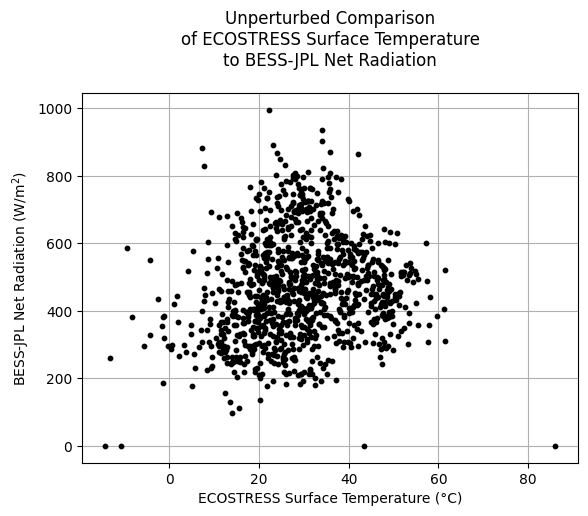

In [8]:
plt.scatter(x=processed.ST_C, y=processed.Rn_Wm2, color='black', s=10, zorder=5)
plt.grid(True, zorder=0)
plt.xlabel("ECOSTRESS Surface Temperature (°C)")
plt.ylabel("BESS-JPL Net Radiation (W/m$^2$)")
plt.title("Unperturbed Comparison\nof ECOSTRESS Surface Temperature\nto BESS-JPL Net Radiation", pad=20)

plt.savefig("Unperturbed Comparison of ECOSTRESS Surface Temperature to BESS-JPL Net Radiation.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Unperturbed Comparison of ECOSTRESS Surface Temperature to BESS-JPL Net Radiation.svg", format='svg', bbox_inches='tight')

plt.show()

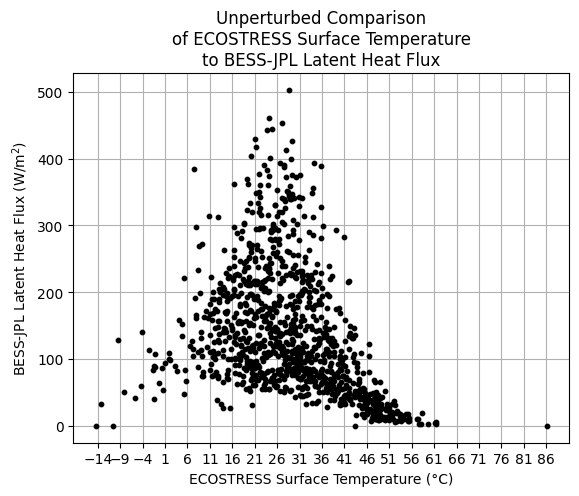

In [9]:
plt.xticks(range(int(min(processed.ST_C)), int(max(processed.ST_C)) + 1, 5))
plt.scatter(x=processed.ST_C, y=processed.LE_Wm2, color='black', s=10, zorder=5)
plt.grid(True, zorder=0)
plt.xlabel("ECOSTRESS Surface Temperature (°C)")
plt.ylabel("BESS-JPL Latent Heat Flux (W/m$^2$)")
plt.title("Unperturbed Comparison\nof ECOSTRESS Surface Temperature\nto BESS-JPL Latent Heat Flux")

plt.savefig("Unperturbed Comparison of ECOSTRESS Surface Temperature to BESS-JPL Latent Heat Flux.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Unperturbed Comparison of ECOSTRESS Surface Temperature to BESS-JPL Latent Heat Flux.svg", format='svg', bbox_inches='tight')

plt.show()

## Further Filter Input Data and Check Temperature Range

This cell applies additional filters to the input data, ensuring only valid `fAPARmax` and `NDVI` values are included. It also checks the minimum and maximum surface temperature values in the filtered dataset.

In [10]:
# input_df = pd.read_csv(input_filename)
input_df = load_ECOv002_calval_BESS_inputs()

if "Ta" in input_df and "Ta_C" not in input_df:
    # input_df.rename({"Ta": "Ta_C"}, inplace=True)
    input_df["Ta_C"] = input_df["Ta"]

input_df = input_df[input_df.NDVI.apply(lambda NDVI: NDVI > 0.05)]

np.nanmin(input_df.ST_C), np.nanmax(input_df.ST_C)

(np.float64(-13.189999999999998), np.float64(86.11000000000001))

## Check Number of Valid Input Rows

This cell displays the number of rows remaining in the input DataFrame after all filtering steps, confirming the size of the dataset used for analysis.

In [11]:
len(input_df)

1063

## Run Perturbed Model Analysis

This cell sets up the input and output variables for the sensitivity analysis and runs the `perturbed_run` function, which perturbs the input variable and observes the effect on the output variable using the BESS-JPL model. The results are displayed for further analysis.

In [12]:
input_variable = "ST_C"
output_variable = "Rn_Wm2"

Rn_results = perturbed_run(
    input_df=input_df, 
    input_variable=input_variable, 
    output_variable=output_variable, 
    forward_process=process_BESS_table,
    normalization_function=normalization_function
)

Rn_results

[2025-12-22 14:53:44 INFO] tarting Monte Carlo perturbed run
[2025-12-22 14:53:44 INFO] calculating standard deviation of input variable: ST_C
[2025-12-22 14:53:44 INFO] input variable ST_C standard deviation: 12.285657205245933
[2025-12-22 14:53:44 INFO] starting forward process
[2025-12-22 14:53:44 INFO] started extracting geometry from BESS input table
[2025-12-22 14:53:44 INFO] completed extracting geometry from PT-JPL-SM input table
[2025-12-22 14:53:44 INFO] started extracting time from BESS input table
[2025-12-22 14:53:44 INFO] All GEOS-5 FP inputs provided, no retrieval needed.
[2025-12-22 14:53:44 INFO] completed extracting time from PT-JPL-SM input table
[2025-12-22 14:53:44 INFO] variable elevation_m min: 1.000 mean: 994.252 max: 3504.000 nan: 0.00% (nan)
[2025-12-22 14:53:44 INFO] All GEOS-5 FP inputs provided, no retrieval needed.
[2025-12-22 14:53:44 INFO] variable Ta_C min: -14.605 mean: 22.380 max: 39.710 nan: 0.00% (nan)
[2025-12-22 14:53:44 INFO] variable RH min: 0.2

,input_variable,output_variable,input_unperturbed,input_perturbation,input_perturbation_std,input_perturbed,output_unperturbed,output_perturbation,output_perturbation_std,output_perturbed
0,ST_C,Rn_Wm2,31.95,-9.214963,0.288418,22.735037,466.357577,224.123192,0.480582,690.480769
1,ST_C,Rn_Wm2,31.95,11.843275,0.370682,43.793275,466.357577,-193.996984,0.415983,272.360593
2,ST_C,Rn_Wm2,31.95,9.395271,0.294062,41.345271,466.357577,-153.581566,0.329321,312.776011
3,ST_C,Rn_Wm2,31.95,-4.868395,0.152375,27.081605,466.357577,119.041761,0.255259,585.399338
4,ST_C,Rn_Wm2,31.95,-1.813393,0.056757,30.136607,466.357577,44.509808,0.095441,510.867385
...,...,...,...,...,...,...,...,...,...,...
106295,ST_C,Rn_Wm2,41.61,21.621818,0.519630,63.231818,579.00815,-315.292204,0.544538,263.715946
106296,ST_C,Rn_Wm2,41.61,8.127025,0.195314,49.737025,579.00815,-146.358227,0.252774,432.649923
106297,ST_C,Rn_Wm2,41.61,-33.912892,0.815018,7.697108,579.00815,420.99185,0.727091,1000.000000
106298,ST_C,Rn_Wm2,41.61,0.788281,0.018945,42.398281,579.00815,-14.014281,0.024204,564.993869


In [13]:
input_variable = "ST_C"
output_variable = "LE_Wm2"

LE_results = perturbed_run(
    input_df=input_df, 
    input_variable=input_variable, 
    output_variable=output_variable, 
    forward_process=process_BESS_table,
    normalization_function=normalization_function
)

LE_results

[2025-12-22 14:53:52 INFO] tarting Monte Carlo perturbed run
[2025-12-22 14:53:52 INFO] calculating standard deviation of input variable: ST_C
[2025-12-22 14:53:52 INFO] input variable ST_C standard deviation: 12.285657205245933
[2025-12-22 14:53:52 INFO] starting forward process
[2025-12-22 14:53:52 INFO] started extracting geometry from BESS input table
[2025-12-22 14:53:52 INFO] completed extracting geometry from PT-JPL-SM input table
[2025-12-22 14:53:52 INFO] started extracting time from BESS input table
[2025-12-22 14:53:52 INFO] All GEOS-5 FP inputs provided, no retrieval needed.
[2025-12-22 14:53:52 INFO] completed extracting time from PT-JPL-SM input table
[2025-12-22 14:53:52 INFO] variable elevation_m min: 1.000 mean: 994.252 max: 3504.000 nan: 0.00% (nan)
[2025-12-22 14:53:52 INFO] All GEOS-5 FP inputs provided, no retrieval needed.
[2025-12-22 14:53:52 INFO] variable Ta_C min: -14.605 mean: 22.380 max: 39.710 nan: 0.00% (nan)
[2025-12-22 14:53:52 INFO] variable RH min: 0.2

,input_variable,output_variable,input_unperturbed,input_perturbation,input_perturbation_std,input_perturbed,output_unperturbed,output_perturbation,output_perturbation_std,output_perturbed
0,ST_C,LE_Wm2,31.95,1.891116,0.059190,33.841116,203.719064,-18.708506,0.091835,185.010559
1,ST_C,LE_Wm2,31.95,-12.646802,0.395831,19.303198,203.719064,184.86141,0.907433,388.580474
2,ST_C,LE_Wm2,31.95,2.738810,0.085722,34.68881,203.719064,-26.765663,0.131385,176.953401
3,ST_C,LE_Wm2,31.95,6.654201,0.208269,38.604201,203.719064,-64.354379,0.315898,139.364685
4,ST_C,LE_Wm2,31.95,4.545951,0.142283,36.495951,203.719064,-44.025386,0.216108,159.693678
...,...,...,...,...,...,...,...,...,...,...
106295,ST_C,LE_Wm2,41.61,0.172325,0.004141,41.782325,81.617643,-1.252601,0.015347,80.365042
106296,ST_C,LE_Wm2,41.61,-15.987196,0.384215,25.622804,81.617643,142.375702,1.744423,223.993345
106297,ST_C,LE_Wm2,41.61,-0.164295,0.003948,41.445705,81.617643,1.211247,0.014841,82.828890
106298,ST_C,LE_Wm2,41.61,-13.223347,0.317793,28.386653,81.617643,118.133279,1.447399,199.750922


## Filter Out NaN Results

This cell removes any rows with missing values from the perturbed results to ensure only valid data points are used in subsequent analysis and plotting.

In [14]:
filtered_Rn_results = Rn_results.dropna()
filtered_Rn_results

,input_variable,output_variable,input_unperturbed,input_perturbation,input_perturbation_std,input_perturbed,output_unperturbed,output_perturbation,output_perturbation_std,output_perturbed
0,ST_C,Rn_Wm2,31.95,-9.214963,0.288418,22.735037,466.357577,224.123192,0.480582,690.480769
1,ST_C,Rn_Wm2,31.95,11.843275,0.370682,43.793275,466.357577,-193.996984,0.415983,272.360593
2,ST_C,Rn_Wm2,31.95,9.395271,0.294062,41.345271,466.357577,-153.581566,0.329321,312.776011
3,ST_C,Rn_Wm2,31.95,-4.868395,0.152375,27.081605,466.357577,119.041761,0.255259,585.399338
4,ST_C,Rn_Wm2,31.95,-1.813393,0.056757,30.136607,466.357577,44.509808,0.095441,510.867385
...,...,...,...,...,...,...,...,...,...,...
106295,ST_C,Rn_Wm2,41.61,21.621818,0.519630,63.231818,579.00815,-315.292204,0.544538,263.715946
106296,ST_C,Rn_Wm2,41.61,8.127025,0.195314,49.737025,579.00815,-146.358227,0.252774,432.649923
106297,ST_C,Rn_Wm2,41.61,-33.912892,0.815018,7.697108,579.00815,420.99185,0.727091,1000.000000
106298,ST_C,Rn_Wm2,41.61,0.788281,0.018945,42.398281,579.00815,-14.014281,0.024204,564.993869


In [15]:
filtered_LE_results = LE_results.dropna()
filtered_LE_results

,input_variable,output_variable,input_unperturbed,input_perturbation,input_perturbation_std,input_perturbed,output_unperturbed,output_perturbation,output_perturbation_std,output_perturbed
0,ST_C,LE_Wm2,31.95,1.891116,0.059190,33.841116,203.719064,-18.708506,0.091835,185.010559
1,ST_C,LE_Wm2,31.95,-12.646802,0.395831,19.303198,203.719064,184.86141,0.907433,388.580474
2,ST_C,LE_Wm2,31.95,2.738810,0.085722,34.68881,203.719064,-26.765663,0.131385,176.953401
3,ST_C,LE_Wm2,31.95,6.654201,0.208269,38.604201,203.719064,-64.354379,0.315898,139.364685
4,ST_C,LE_Wm2,31.95,4.545951,0.142283,36.495951,203.719064,-44.025386,0.216108,159.693678
...,...,...,...,...,...,...,...,...,...,...
106295,ST_C,LE_Wm2,41.61,0.172325,0.004141,41.782325,81.617643,-1.252601,0.015347,80.365042
106296,ST_C,LE_Wm2,41.61,-15.987196,0.384215,25.622804,81.617643,142.375702,1.744423,223.993345
106297,ST_C,LE_Wm2,41.61,-0.164295,0.003948,41.445705,81.617643,1.211247,0.014841,82.828890
106298,ST_C,LE_Wm2,41.61,-13.223347,0.317793,28.386653,81.617643,118.133279,1.447399,199.750922


## Plot Change in Surface Temperature vs Net Radiation

This cell generates a scatter plot showing the relationship between changes in surface temperature and changes in BESS-JPL net radiation due to input perturbations. The plot is saved as JPEG and SVG files.

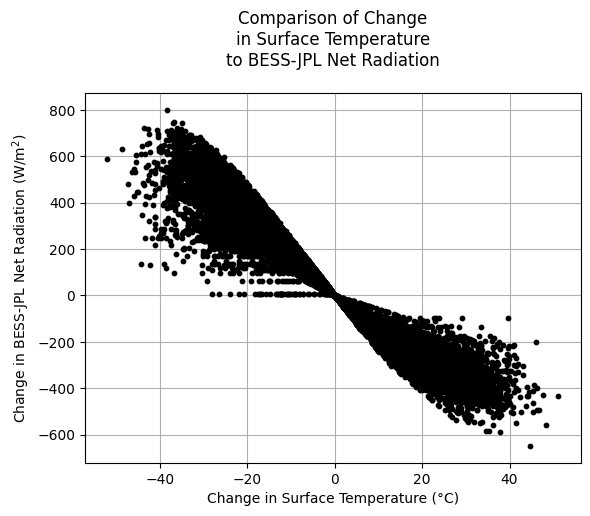

In [16]:
# plt.xticks(range(int(min(processed.ST_C)), int(max(processed.ST_C)) + 1, 5))
# plt.ylim(-350, 150)
plt.scatter(x=Rn_results.input_perturbation, y=Rn_results.output_perturbation, color='black', s=10, zorder=5)  # Adjust the 's' parameter to make dots thinner
plt.grid(True, zorder=0)
plt.xlabel("Change in Surface Temperature (°C)")
plt.ylabel("Change in BESS-JPL Net Radiation (W/m$^2$)")
plt.title("Comparison of Change\nin Surface Temperature\nto BESS-JPL Net Radiation", pad=20)

plt.savefig("Comparison of Change in Surface Temperature to BESS-JPL Net Radiation.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Comparison of Change in Surface Temperature to BESS-JPL Net Radiation.svg", format='svg', bbox_inches='tight')

plt.show()

In [17]:
Rn_results.columns

Index(['input_variable', 'output_variable', 'input_unperturbed',
       'input_perturbation', 'input_perturbation_std', 'input_perturbed',
       'output_unperturbed', 'output_perturbation', 'output_perturbation_std',
       'output_perturbed'],
      dtype='object')

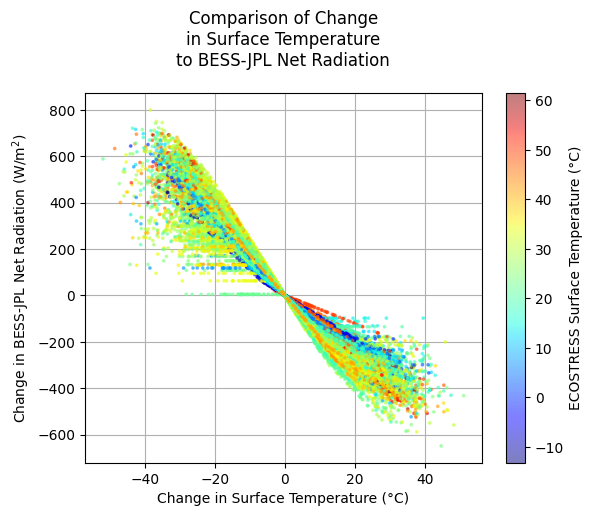

In [18]:
sc = plt.scatter(
    x=Rn_results.input_perturbation, 
    y=Rn_results.output_perturbation, 
    c=Rn_results.input_unperturbed, 
    color=None,
    cmap="jet",
    s=3,
    alpha=0.5, 
    zorder=5
)

plt.grid(True, zorder=0)
plt.xlabel("Change in Surface Temperature (°C)")
plt.ylabel("Change in BESS-JPL Net Radiation (W/m$^2$)")
plt.title("Comparison of Change\nin Surface Temperature\nto BESS-JPL Net Radiation", pad=20)
plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")
plt.savefig("Comparison of Change in Surface Temperature to BESS-JPL Net Radiation.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Comparison of Change in Surface Temperature to BESS-JPL Net Radiation.svg", format='svg', bbox_inches='tight')

plt.show()

In [19]:
# ST_Rn_aggregated_perturbation = Rn_results.groupby("input_unperturbed")["output_perturbation"].mean().reset_index()
# ST_Rn_aggregated_perturbation

In [20]:
# sc = plt.scatter(
#     x=Rn_results.input_unperturbed, 
#     y=Rn_results.output_perturbation, 
#     color="Black",
#     s=10, 
#     zorder=5
# )

# plt.grid(True, zorder=0)
# plt.xlabel("ECOSTRESS Surface Temperature (°C)")
# plt.ylabel("Average Change in BESS-JPL Net Radiation (W/m$^2$)")
# plt.title("Comparison of Change\nin Surface Temperature\nto BESS-JPL Net Radiation", pad=20)
# plt.savefig("Comparison of Surface Temperature to Change in BESS-JPL Net Radiation.jpeg", format='jpeg', bbox_inches='tight')
# plt.savefig("Comparison of Surface Temperature to Change in BESS-JPL Net Radiation.svg", format='svg', bbox_inches='tight')

# plt.show()

## Plot Change in Surface Temperature vs Latent Heat Flux

This cell generates a scatter plot showing the relationship between changes in surface temperature and changes in BESS-JPL latent heat flux due to input perturbations. The plot is saved as JPEG and SVG files.

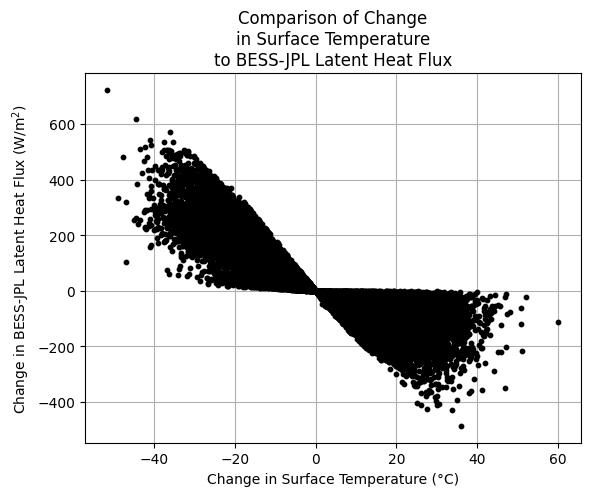

In [21]:
plt.scatter(x=LE_results.input_perturbation, y=LE_results.output_perturbation, color='black', s=10, zorder=5)  # Adjust the 's' parameter to make dots thinner
plt.grid(True, zorder=0)
plt.xlabel("Change in Surface Temperature (°C)")
plt.ylabel("Change in BESS-JPL Latent Heat Flux (W/m$^2$)")
plt.title("Comparison of Change\nin Surface Temperature\nto BESS-JPL Latent Heat Flux")

plt.savefig("Comparison of Change in Surface Temperature to BESS-JPL Latent Heat Flux.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Comparison of Change in Surface Temperature to BESS-JPL Latent Heat Flux.svg", format='svg', bbox_inches='tight')

plt.show()

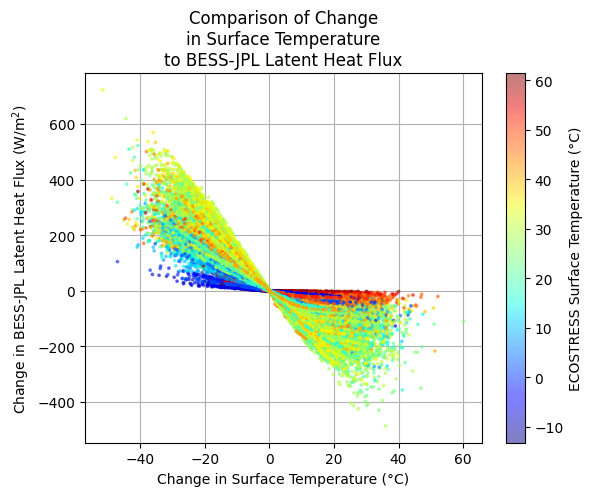

In [22]:
sc = plt.scatter(
    x=LE_results.input_perturbation, 
    y=LE_results.output_perturbation, 
    c=LE_results.input_unperturbed, 
    color=None,
    cmap="jet",
    s=3,
    alpha=0.5, 
    zorder=5
)

plt.grid(True, zorder=0)
plt.xlabel("Change in Surface Temperature (°C)")
plt.ylabel("Change in BESS-JPL Latent Heat Flux (W/m$^2$)")
plt.title("Comparison of Change\nin Surface Temperature\nto BESS-JPL Latent Heat Flux")
plt.colorbar(sc, label="ECOSTRESS Surface Temperature (°C)")
plt.savefig("Comparison of Change in Surface Temperature to BESS-JPL Latent Heat Flux.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("Comparison of Change in Surface Temperature to BESS-JPL Latent Heat Flux.svg", format='svg', bbox_inches='tight')

plt.show()

## Compute Correlation Between Input and Output Perturbations

This cell calculates the Pearson correlation coefficient between the standardized input and output perturbations, quantifying the strength of their linear relationship.

In [23]:
correlation = mstats.pearsonr(
    np.array(filtered_Rn_results.input_perturbation_std).astype(np.float64), 
    np.array(filtered_Rn_results.output_perturbation_std).astype(np.float64)
)[0]

correlation

np.float64(0.13639940801753137)

## Run Full Sensitivity Analysis for Multiple Inputs

This cell performs a comprehensive sensitivity analysis by perturbing several input variables (surface temperature, NDVI, albedo, air temperature, relative humidity) and measuring their effect on latent heat flux. The results are summarized in a DataFrame.

In [ ]:
input_variables = ["ST_C", "albedo", "Ta_C", "RH", "AOT", "COT"]
output_variables = ["Rn_Wm2"]

Rn_perturbation_df, Rn_sensitivity_metrics_df = sensitivity_analysis(
    input_df=input_df,
    input_variables=input_variables,
    output_variables=output_variables,
    forward_process=process_BESS_table,
    normalization_function=normalization_function
)

Rn_sensitivity_metrics_df

[2025-12-22 14:57:05 INFO] tarting Monte Carlo perturbed run
[2025-12-22 14:57:05 INFO] calculating standard deviation of input variable: ST_C
[2025-12-22 14:57:05 INFO] input variable ST_C standard deviation: 12.285657205245933
[2025-12-22 14:57:05 INFO] starting forward process
[2025-12-22 14:57:05 INFO] started extracting geometry from BESS input table
[2025-12-22 14:57:05 INFO] completed extracting geometry from PT-JPL-SM input table
[2025-12-22 14:57:05 INFO] started extracting time from BESS input table
[2025-12-22 14:57:05 INFO] All GEOS-5 FP inputs provided, no retrieval needed.
[2025-12-22 14:57:05 INFO] completed extracting time from PT-JPL-SM input table
[2025-12-22 14:57:05 INFO] variable elevation_m min: 1.000 mean: 994.252 max: 3504.000 nan: 0.00% (nan)
[2025-12-22 14:57:05 INFO] All GEOS-5 FP inputs provided, no retrieval needed.
[2025-12-22 14:57:05 INFO] variable Ta_C min: -14.605 mean: 22.380 max: 39.710 nan: 0.00% (nan)
[2025-12-22 14:57:05 INFO] variable RH min: 0.2

/opt/homebrew/Caskroom/miniforge/base/envs/BESS-JPL/lib/python3.11/site-packages/monte_carlo_sensitivity/sensitivity_analysis.py:77: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  perturbation_df = pd.concat([perturbation_df, run_results])
/opt/homebrew/Caskroom/miniforge/base/envs/BESS-JPL/lib/python3.11/site-packages/monte_carlo_sensitivity/sensitivity_analysis.py:89: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  sensitivity_metrics_df = pd.concat([sensitivity_metrics_df, pd.DataFrame([[


[2025-12-22 14:57:12 INFO] variable desTa min: 16.249 mean: 177.138 max: 387.676 nan: 0.00% (nan)
[2025-12-22 14:57:12 INFO] variable ddesTa min: 1.197 mean: 9.183 max: 17.906 nan: 0.00% (nan)
[2025-12-22 14:57:12 INFO] variable gamma min: 42.603 mean: 60.196 max: 68.164 nan: 0.00% (nan)
[2025-12-22 14:57:12 INFO] variable Cp min: 1005.900 mean: 1012.867 max: 1022.895 nan: 0.00% (nan)
[2025-12-22 14:57:12 INFO] variable rhoa min: 0.776 mean: 1.067 max: 1.314 nan: 0.00% (nan)
[2025-12-22 14:57:12 INFO] variable epsa min: 0.663 mean: 0.771 max: 0.879 nan: 0.00% (nan)
[2025-12-22 14:57:12 INFO] variable R min: 459.769 mean: 906.194 max: 1000.000 nan: 0.00% (nan)
[2025-12-22 14:57:12 INFO] variable Rc min: 459.769 mean: 906.194 max: 1000.000 nan: 0.00% (nan)
[2025-12-22 14:57:12 INFO] variable Rs min: 229.885 mean: 453.097 max: 500.000 nan: 0.00% (nan)
[2025-12-22 14:57:12 INFO] variable SFd min: 0.020 mean: 0.051 max: 0.083 nan: 0.00% (nan)
[2025-12-22 14:57:12 INFO] variable SFd2 min: 0.

,input_variable,output_variable,metric,value
0,ST_C,Rn_Wm2,correlation,0.137406
0,ST_C,Rn_Wm2,r2,0.018880
0,ST_C,Rn_Wm2,mean_normalized_change,0.364027
0,albedo,Rn_Wm2,correlation,0.612094
0,albedo,Rn_Wm2,r2,0.374659
0,albedo,Rn_Wm2,mean_normalized_change,0.059703
0,Ta_C,Rn_Wm2,correlation,0.062653
0,Ta_C,Rn_Wm2,r2,0.003925
0,Ta_C,Rn_Wm2,mean_normalized_change,0.255722
0,RH,Rn_Wm2,correlation,0.473476


In [29]:
input_variables = ["ST_C", "NDVI", "albedo", "Ta_C", "RH"]
output_variables = ["LE_Wm2"]

LE_perturbation_df, LE_sensitivity_metrics_df = sensitivity_analysis(
    input_df=input_df,
    input_variables=input_variables,
    output_variables=output_variables,
    forward_process=process_BESS_table,
    normalization_function=normalization_function
)

LE_sensitivity_metrics_df

[2025-12-22 14:57:43 INFO] tarting Monte Carlo perturbed run
[2025-12-22 14:57:43 INFO] calculating standard deviation of input variable: ST_C
[2025-12-22 14:57:43 INFO] input variable ST_C standard deviation: 12.285657205245933
[2025-12-22 14:57:43 INFO] starting forward process
[2025-12-22 14:57:43 INFO] started extracting geometry from BESS input table
[2025-12-22 14:57:43 INFO] completed extracting geometry from PT-JPL-SM input table
[2025-12-22 14:57:43 INFO] started extracting time from BESS input table
[2025-12-22 14:57:43 INFO] All GEOS-5 FP inputs provided, no retrieval needed.
[2025-12-22 14:57:43 INFO] completed extracting time from PT-JPL-SM input table
[2025-12-22 14:57:43 INFO] variable elevation_m min: 1.000 mean: 994.252 max: 3504.000 nan: 0.00% (nan)
[2025-12-22 14:57:43 INFO] All GEOS-5 FP inputs provided, no retrieval needed.
[2025-12-22 14:57:43 INFO] variable Ta_C min: -14.605 mean: 22.380 max: 39.710 nan: 0.00% (nan)
[2025-12-22 14:57:43 INFO] variable RH min: 0.2

/opt/homebrew/Caskroom/miniforge/base/envs/BESS-JPL/lib/python3.11/site-packages/monte_carlo_sensitivity/sensitivity_analysis.py:77: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  perturbation_df = pd.concat([perturbation_df, run_results])
/opt/homebrew/Caskroom/miniforge/base/envs/BESS-JPL/lib/python3.11/site-packages/monte_carlo_sensitivity/sensitivity_analysis.py:89: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  sensitivity_metrics_df = pd.concat([sensitivity_metrics_df, pd.DataFrame([[


[2025-12-22 14:57:51 INFO] variable VCmax_C4_sunlit_μmolm2s1 min: 1.438 mean: 30.612 max: 148.721 nan: 0.00% (nan)
[2025-12-22 14:57:51 INFO] variable VCmax_C3_shaded_μmolm2s1 min: 0.060 mean: 36.813 max: 264.371 nan: 0.00% (nan)
[2025-12-22 14:57:51 INFO] variable VCmax_C4_shaded_μmolm2s1 min: 0.060 mean: 31.494 max: 264.371 nan: 0.00% (nan)
[2025-12-22 14:57:51 INFO] variable PARDiff min: 18.773 mean: 40.472 max: 158.456 nan: 0.00% (nan)
[2025-12-22 14:57:51 INFO] variable PARDir min: 61.502 mean: 281.809 max: 473.257 nan: 0.00% (nan)
[2025-12-22 14:57:51 INFO] variable NIRDiff min: 0.000 mean: 8.459 max: 95.964 nan: 0.00% (nan)
[2025-12-22 14:57:51 INFO] variable NIRDir min: 118.387 mean: 361.835 max: 591.598 nan: 0.00% (nan)
[2025-12-22 14:57:51 INFO] variable UV min: 14.174 mean: 43.044 max: 76.912 nan: 0.00% (nan)
[2025-12-22 14:57:51 INFO] variable SZA min: 8.815 mean: 44.908 max: 72.288 nan: 0.00% (nan)
[2025-12-22 14:57:51 INFO] variable LAI min: 0.076 mean: 1.285 max: 4.516 n

,input_variable,output_variable,metric,value
0,ST_C,LE_Wm2,correlation,0.030740
0,ST_C,LE_Wm2,r2,0.000945
0,ST_C,LE_Wm2,mean_normalized_change,0.771109
0,NDVI,LE_Wm2,correlation,0.665560
0,NDVI,LE_Wm2,r2,0.442970
0,NDVI,LE_Wm2,mean_normalized_change,0.266391
0,albedo,LE_Wm2,correlation,0.451084
0,albedo,LE_Wm2,r2,0.203477
0,albedo,LE_Wm2,mean_normalized_change,0.079620
0,Ta_C,LE_Wm2,correlation,0.031703


## Plot Sensitivity Magnitude Bar Chart

This cell creates a bar chart showing the average percent change in latent heat flux for each input variable, visualizing the magnitude of model sensitivity to each input. The plot is saved as JPEG and SVG files with the BESS-JPL label.

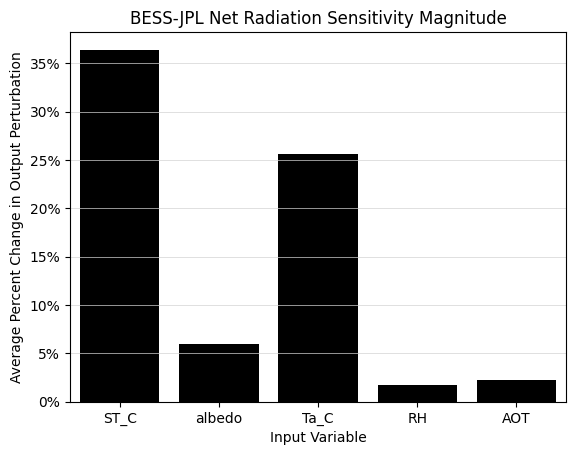

In [30]:
df = Rn_sensitivity_metrics_df
df = df[(df.output_variable == "Rn_Wm2") & (df.metric == "mean_normalized_change")]
ax = sns.barplot(x=df.input_variable, y=df.value * 100, color='black')
# ax.set_xticklabels(["Surface\nTemperature", "Albedo", "Air\nTemperature", "Relative\nHumidity"])
plt.xlabel("Input Variable")
plt.ylabel("Average Percent Change in Output Perturbation")
plt.title("BESS-JPL Net Radiation Sensitivity Magnitude")
# plt.ylim(0, 160)  # Set y-axis range from 0 to 160
plt.grid(axis='y', color='lightgray', linestyle='-', linewidth=0.5)  # Add light gray horizontal gridlines only

# Add percent sign to y-axis tick labels
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{int(y)}%'))

plt.savefig("BESS-JPL Net Radiation Sensitivity Magnitude.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("BESS-JPL Net Radiation Sensitivity Magnitude.svg", format='svg', bbox_inches='tight')

plt.show()

/var/folders/bv/410kt7f93x78j9dww00h1pz80000gn/T/ipykernel_15928/3947530048.py:4: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Surface\nTemperature", "NDVI", "Albedo", "Air\nTemperature", "Relative\nHumidity"])


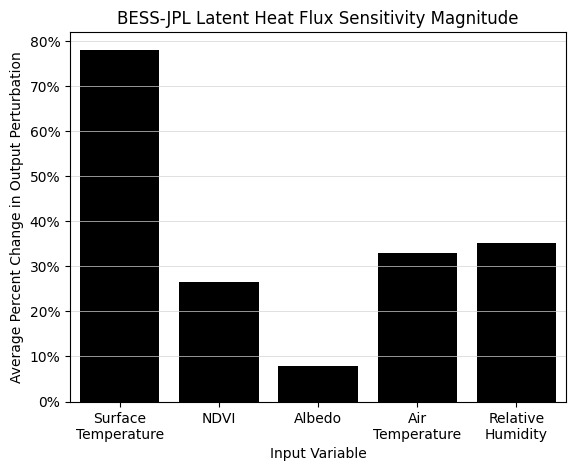

In [27]:
df = LE_sensitivity_metrics_df
df = df[(df.output_variable == "LE_Wm2") & (df.metric == "mean_normalized_change")]
ax = sns.barplot(x=df.input_variable, y=df.value * 100, color='black')
ax.set_xticklabels(["Surface\nTemperature", "NDVI", "Albedo", "Air\nTemperature", "Relative\nHumidity"])
plt.xlabel("Input Variable")
plt.ylabel("Average Percent Change in Output Perturbation")
plt.title("BESS-JPL Latent Heat Flux Sensitivity Magnitude")
# plt.ylim(0, 160)  # Set y-axis range from 0 to 160
plt.grid(axis='y', color='lightgray', linestyle='-', linewidth=0.5)  # Add light gray horizontal gridlines only

# Add percent sign to y-axis tick labels
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, _: f'{int(y)}%'))

plt.savefig("BESS-JPL Latent Heat Flux Sensitivity Magnitude.jpeg", format='jpeg', bbox_inches='tight')
plt.savefig("BESS-JPL Latent Heat Flux Sensitivity Magnitude.svg", format='svg', bbox_inches='tight')

plt.show()

## Summary and Next Steps

This notebook demonstrated a full sensitivity analysis workflow for the BESS-JPL model using ECOSTRESS Cal-Val data. Key results include the identification of input variables with the greatest influence on latent heat flux. Next steps could include further exploration of model parameters, additional visualizations, or application to other datasets.